## *Libraries Import*

In [ ]:
import random
import tqdm
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

## *Dataset*

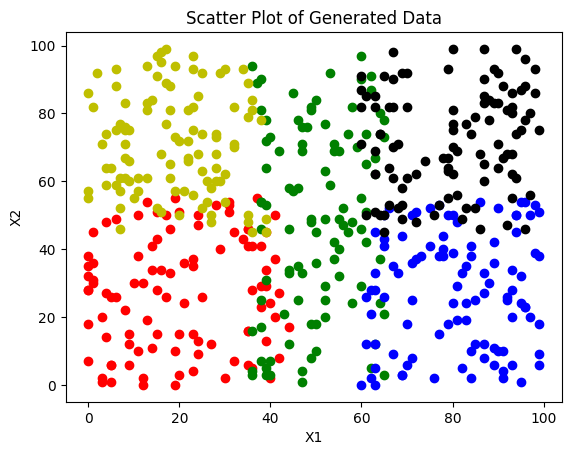

In [ ]:
np.random.seed(0)
# Number of samples
n_samples = 500

# Define ranges
ranges1 = [(0, 45), (36, 66), (60, 100), (0, 40), (60, 100)]
ranges2 = [(0, 56), (0, 100), (0, 55), (45, 100), (45, 100)]

# Generate the dataset
X1 = np.concatenate([np.random.randint(r_min, r_max, size=(n_samples // 5, 1)) for r_min, r_max in ranges1])
X2 = np.concatenate([np.random.randint(r_min, r_max, size=(n_samples // 5, 1)) for r_min, r_max in ranges2])
X = np.hstack((X1, X2)) #horizontal stacking

# Generate labels
Y = np.array([i for i in range(5) for repeat in range(n_samples // 5)])

# Plotting
colors = ['ro', 'go', 'bo', 'yo', 'ko']
for i, (x1, x2) in enumerate(X):
    plt.plot(x1, x2, colors[Y[i]])

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Scatter Plot of Generated Data')
plt.show()

Y = OneHotEncoder(sparse_output=False).fit_transform(Y.reshape(-1, 1)) #coverts categorical data into binary matrix

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42) #Train= 80%; test=20%


## *Neural Network Model Building*

In [ ]:
class NeuralNetwork(object):
    def __init__(self):
        #define neurons
        inputLayerNeurons = 2
        hiddenLayer1Neurons =12
        hiddenLayer2Neurons = 10
        hiddenLayer3Neurons = 8
        outLayerNeurons = 5
        self.learning_rate = 0.009
        #np.random.seed(3)
        #input-hidden1
        self.W_HI = np.random.randn(inputLayerNeurons, hiddenLayer1Neurons)
        self.b_HI = np.random.randn(1, hiddenLayer1Neurons)
        #hidden1-hidden2
        self.W_HH1 = np.random.randn(hiddenLayer1Neurons, hiddenLayer2Neurons)
        self.b_HH1 = np.random.randn(1, hiddenLayer2Neurons)
        #hidden2-hidden3
        self.W_HH2 = np.random.randn(hiddenLayer2Neurons, hiddenLayer3Neurons)
        self.b_HH2 = np.random.randn(1, hiddenLayer3Neurons)
        #hidden3-output
        self.W_OH = np.random.randn(hiddenLayer3Neurons, outLayerNeurons)
        self.b_OH = np.random.randn(1, outLayerNeurons)

    def sigmoid(self, x, der=False):
      if der == True:
        return x * (1-x)
      else:
        return 1 / (1 + np.exp(-x))

    def relu(self, x, der=False):
        if der:
            return np.where(x > 0, 1, 0)
        else:
            return np.maximum(0, x)

    def softmax(self, x, der=False):
      if der:
        for i in range(len(x)):
          jacobian_mat = np.diagflat(x[i]) - np.outer(x[i], x[i])
          x[i] = np.max(np.abs(jacobian_mat), axis=1)
        return x
      else:
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def feedForward(self, X):
        hidden_input1 = np.dot(X, self.W_HI) + self.b_HI
        self.hidden_output1 = self.sigmoid(hidden_input1)

        hidden_input2 = np.dot(self.hidden_output1, self.W_HH1) + self.b_HH1
        self.hidden_output2 = self.sigmoid(hidden_input2)

        hidden_input3 = np.dot(self.hidden_output2, self.W_HH2) + self.b_HH2
        self.hidden_output3 = self.sigmoid(hidden_input3)

        output_input = np.dot(self.hidden_output3, self.W_OH) + self.b_OH
        pred = self.softmax(output_input)
        return pred

    def backPropagation(self, X, Y, pred):
        output_error = Y - pred
        output_delta = self.learning_rate * output_error * self.softmax(pred, der=True)

        hidden_error3 = output_delta.dot(self.W_OH.T)
        hidden_delta3 = self.learning_rate * hidden_error3 * self.sigmoid(self.hidden_output3, der=True)

        hidden_error2 = hidden_delta3.dot(self.W_HH2.T)
        hidden_delta2 = self.learning_rate * hidden_error2 * self.sigmoid(self.hidden_output2, der=True)

        hidden_error1 = hidden_delta2.dot(self.W_HH1.T)
        hidden_delta1 = self.learning_rate * hidden_error1 * self.sigmoid(self.hidden_output1, der=True)

        self.W_HI += X.T.dot(hidden_delta1)
        self.b_HI += np.sum(hidden_delta1, axis=0, keepdims=True)

        self.W_HH1 += self.hidden_output1.T.dot(hidden_delta2)
        self.b_HH1 += np.sum(hidden_delta2, axis=0, keepdims=True)

        self.W_HH2 += self.hidden_output2.T.dot(hidden_delta3)
        self.b_HH2 += np.sum(hidden_delta3, axis=0, keepdims=True)

        self.W_OH += self.hidden_output3.T.dot(output_delta)
        self.b_OH += np.sum(output_delta, axis=0, keepdims=True)

    def train(self, X, Y):
        output = self.feedForward(X)
        self.backPropagation(X,Y,output)

## *Model Training*

100%|██████████| 2500/2500 [00:38<00:00, 64.18it/s] 


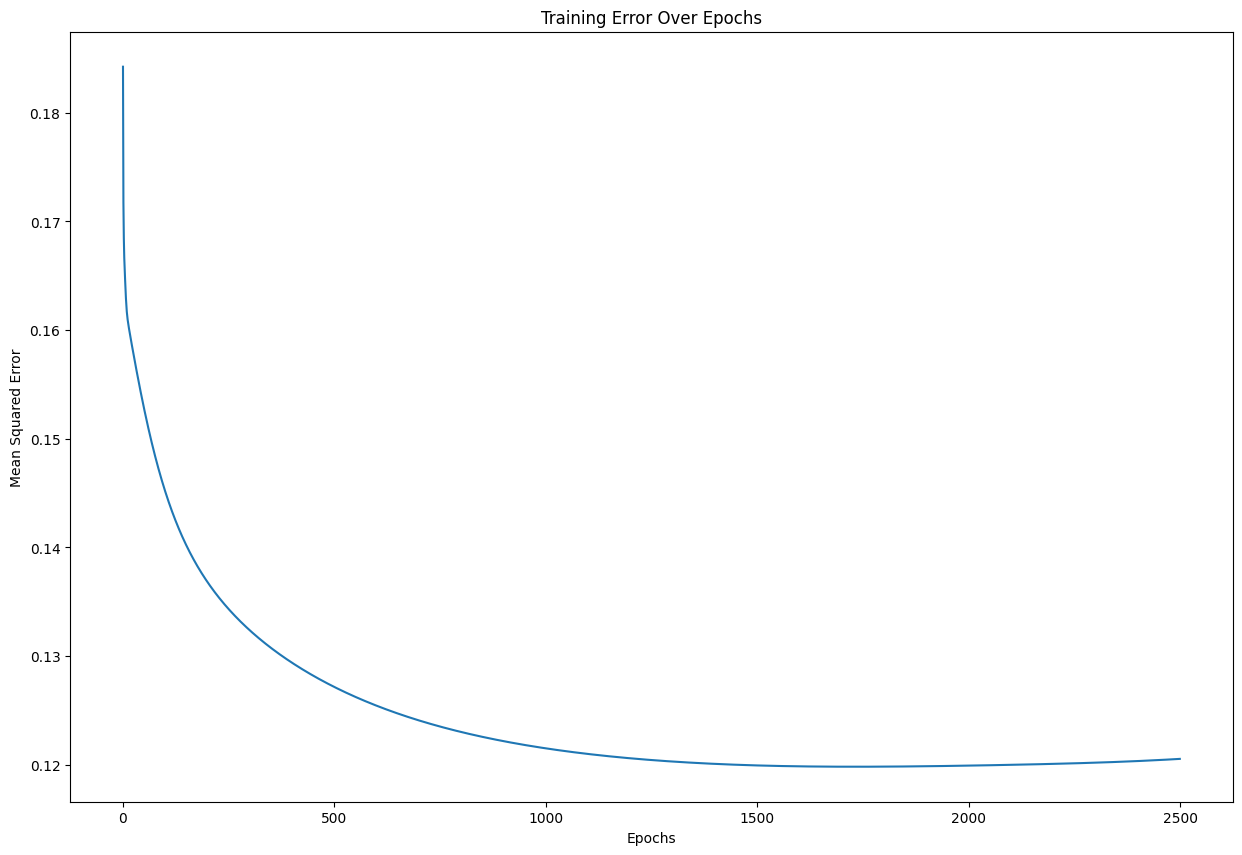

In [ ]:
NN = NeuralNetwork()
err = []
for i in tqdm.tqdm(range(2500)):
  NN.train(X_train,Y_train)
  err.append(np.mean(np.square(Y - NN.feedForward(X))))

plt.figure(figsize=(15,10))
plt.plot(err)
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('Training Error Over Epochs')
plt.show()

## *Model Evaluation*

In [ ]:
pred_probs = NN.feedForward(X_test)
predictions = np.argmax(pred_probs, axis=1)
actual = np.argmax(Y_test, axis=1)

#classification report
print("Classification Report:")
print(classification_report(actual, predictions, target_names=[f'Class {i}' for i in range(5)], zero_division=0))

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00        28
     Class 1       0.33      0.21      0.26        14
     Class 2       0.30      0.60      0.40        10
     Class 3       0.62      0.96      0.75        24
     Class 4       0.59      0.83      0.69        24

    accuracy                           0.52       100
   macro avg       0.37      0.52      0.42       100
weighted avg       0.37      0.52      0.42       100



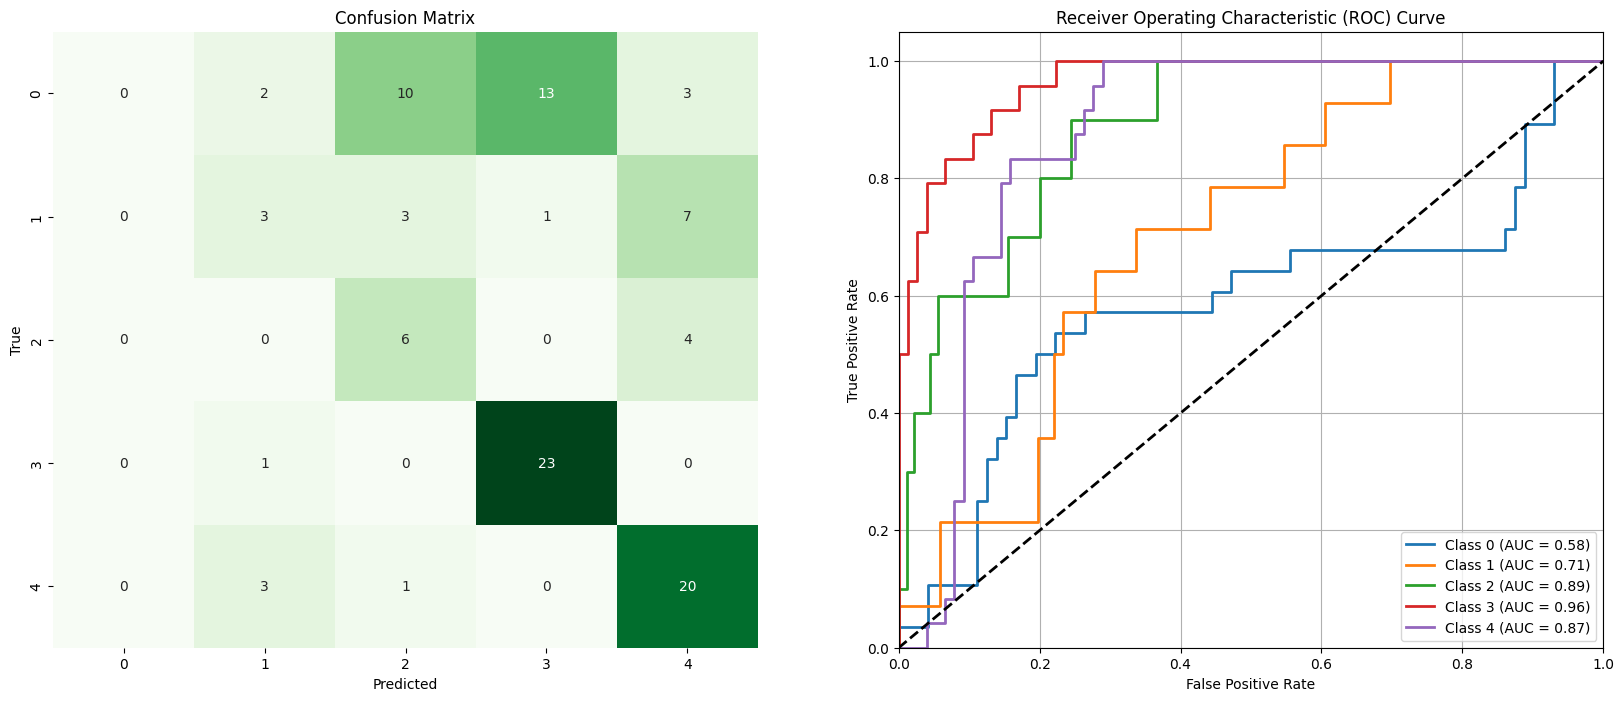

In [6]:
plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1 )
#confusion matrix
conf_matrix = confusion_matrix(actual, predictions)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=[f'{i}' for i in range(5)],
            yticklabels=[f'{i}' for i in range(5)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

plt.subplot(1, 2, 2)
#roc curve
for i in range(5):
    fpr, tpr, _ = roc_curve(Y_test[:, i], pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()

## *Documentation for Multi-Class Classification Implementation*

### Overview

This code is designed to train a simple neural network to classify data into one of five different categories. Each category is represented by a specific range of feature values, and the goal is for the neural network to learn how to accurately categorize new data based on these features.

This documentation breaks down the key modifications made to the original code to enable it to handle multi-class classification, explaining each part of the process in a way that's easy to understand.

### Modifications for Multi-Class Classification

1. **Creating the Data**:
   - We created a dataset with two features, `ranges1` and `ranges2`. Each of the five classes has its own range of values for these features. The features are combined into a single matrix, and each data point is labeled according to its class.

2. **Encoding the Labels**:
   - Since we're working with multiple classes, we converted the labels into a format the neural network can understand using one-hot encoding. This process turns each label into a vector where the correct class is marked as 1, and all other classes are marked as 0.

3. **Building the Neural Network**:
   - The neural network consists of three layers that process the data, with each layer applying a mathematical function called sigmoid to introduce non-linearity. The final layer has five nodes, one for each class, and uses a softmax function to output a probability distribution, indicating the likelihood that a data point belongs to each class.

4. **Processing the Data (Forward Pass)**:
   - The input data is passed through the network. Each layer calculates a weighted sum of its inputs, adds a bias, and then applies the sigmoid function to produce an output. The final layer uses softmax to convert the outputs into probabilities for each class.

5. **Learning from Mistakes (Backward Pass and Weight Updates)**:
   - The network calculates the difference between its predictions and the actual labels. This error is then used to adjust the weights and biases of the network in a way that reduces the error, helping the network learn over time. We use specific formulas to calculate these adjustments for the output layer (softmax derivative) and the hidden layers (sigmoid derivative).

6. **Training the Network**:
   - The network is trained by repeatedly processing the training data and adjusting the weights and biases over many iterations, called epochs. The performance of the network is tracked by calculating the average error at each step and plotting this error to see how well the network is learning.

7. **Evaluating the Network**:
   - After training, the network is tested on new data to see how well it performs. We generate a classification report that shows how accurately the network classifies each class. A confusion matrix is used to visualize where the network makes mistakes, and an ROC curve is plotted to analyze the network's ability to distinguish between classes.

## *Mathematical Representation of the Code*

This section breaks down the mathematical concepts behind each part of the code used for multi-class classification. I'll explain how the code operates and the key formulas involved in a more accessible manner.
1. Generating Synthetic Data

    Feature Generation:
        We create features by generating data points within specific ranges for each of the five classes:
            Class 0:
            Class 1:
            Class 2:
            Class 3:
            Class 4:
    Label Generation:
        Labels are assigned to each data point, so each class is equally represented. For instance, if a data point belongs to Class 0, its label is 0; for Class 1, the label is 1, and so on.

    One-Hot Encoding:
        To handle multiple classes, labels are converted into binary vectors. Each class is represented by a vector where the position of 1 corresponds to the class, and all other positions are 0. For example, if the label is 2, its one-hot encoded vector is [0, 0, 1, 0, 0].

2. Neural Network Architecture

    Input Layer to Hidden Layers:
        Hidden Layers 1, 2, and 3: Each layer processes the input data using weights and biases. The weighted sum for each neuron is calculated as:
        Z=X⋅W+b
        Z=X⋅W+b where XX is the input data, WW are the weights, and bb is the bias.
        Activation Function (Sigmoid): Converts the weighted sum into a value between 0 and 1:
        A=11+e−Z
        A=1+e−Z1​

    Output Layer:
        Softmax Function: The final layer outputs probabilities for each class:
        softmax(zi)=ezi∑jezj
        softmax(zi​)=∑j​ezj​ezi​​ This ensures that the sum of probabilities across all classes is 1, making it easy to interpret the network's output as a probability distribution.

3. Backpropagation and Weight Updates

    Output Layer Error:
        The difference between the predicted probabilities and the actual one-hot encoded labels is calculated to determine the error:
        E=Yonehot−Y^
        E=Yonehot​−Y^

    Hidden Layers Error:
        The error is propagated backward through the network to adjust weights and biases. This involves calculating gradients and updating weights accordingly:
        ΔW=learning_rate⋅error⋅activation′(Z)
        ΔW=learning_rate⋅error⋅activation′(Z) where activation′(Z)activation′(Z) is the derivative of the activation function.

4. Training and Evaluation

    Training Process:
        Mean Squared Error (MSE): Measures how well the network's predictions match the actual labels. It's calculated as:
        MSE=1N∑i=1N∥Yonehot[i]−Y^[i]∥2
        MSE=N1​i=1∑N​∥Yonehot​[i]−Y^[i]∥2 where NN is the number of samples.

    Evaluation Metrics:
        Classification Report: Shows how well the network performs for each class, including precision, recall, and F1-score.
        Confusion Matrix: Displays the number of correct and incorrect predictions for each class, helping visualize the network's performance.
        ROC Curve: Plots the true positive rate against the false positive rate for each class, showing how well the network distinguishes between classes.
        AUC (Area Under Curve): Summarizes the performance of the classifier across all thresholds.